In [3]:
import zipfile
import os

# Define the path to the uploaded ZIP file
zip_path = r"C:\Users\Rakshitha\OneDrive\Desktop\rakshitha\FDS\cust-dna\archive (1).zip"
extract_path = "ecommerce_dataset"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
extracted_files = os.listdir(extract_path)
extracted_files


['data.csv']

In [5]:
import pandas as pd

# Define the path to the extracted CSV file
csv_path = "ecommerce_dataset/data.csv"  # Update this if needed

# Load the dataset (use encoding if needed)
df = pd.read_csv(csv_path, encoding="ISO-8859-1")

# Display basic information
print(df.info())

# Show the first few rows
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED 

In [7]:
# Handling missing values

# Drop rows where 'Description' is missing
df = df.dropna(subset=["Description"])

# Drop rows where 'CustomerID' is missing, as it's crucial for customer analysis
df = df.dropna(subset=["CustomerID"])

# Convert 'CustomerID' to integer (originally float)
df["CustomerID"] = df["CustomerID"].astype(int)

# Convert 'InvoiceDate' to datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove negative or zero 'Quantity' and 'UnitPrice' (likely returns or errors)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove duplicates if any
df = df.drop_duplicates()

# Display cleaned dataset info
df_info_cleaned = df.info()
df_head_cleaned = df.head()

df_info_cleaned, df_head_cleaned


<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 25.5+ MB


(None,
   InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
           InvoiceDate  UnitPrice  CustomerID         Country  
 0 2010-12-01 08:26:00       2.55       17850  United Kingdom  
 1 2010-12-01 08:26:00       3.39       17850  United Kingdom  
 2 2010-12-01 08:26:00       2.75       17850  United Kingdom  
 3 2010-12-01 08:26:00       3.39       17850  United Kingdom  
 4 2010-12-01 08:26:00       3.39       17850  United Kingdom  )

In [9]:
#Total Revenue
#Formula: Total Revenue = Quantity * UnitPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
total_revenue = df['TotalPrice'].sum()
print(f"Total Revenue: ${total_revenue:.2f}")


Total Revenue: $8887208.89


In [11]:
# Average Order Value (AOV)
#Formula: AOV = Total Revenue / Number of Unique Invoices
unique_invoices = df['InvoiceNo'].nunique()
average_order_value = total_revenue / unique_invoices
print(f"Average Order Value: ${average_order_value:.2f}")


Average Order Value: $479.56


In [13]:
#Number of Unique Customers
unique_customers = df['CustomerID'].nunique()
print(f"Number of Unique Customers: {unique_customers}")


Number of Unique Customers: 4338


In [15]:
# Most Sold Products
#Find the products with the highest total quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [17]:
#Top Spending Customers
#Find the customers who spent the most
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64


In [19]:
df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

In [21]:
df.duplicated().sum()


0

In [23]:
df.describe()


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [25]:
df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

In [27]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)


Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [29]:
df.sort_values(by="TotalPrice", ascending=False).head(5)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.00
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450,United Kingdom,7144.72


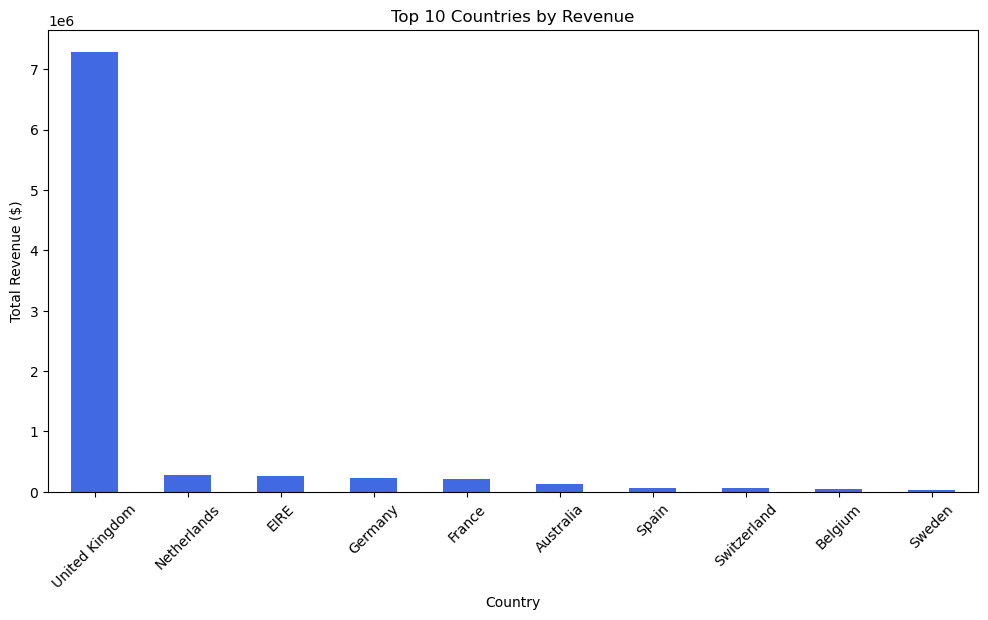

In [31]:
import matplotlib.pyplot as plt

df_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
df_country.plot(kind="bar", color="royalblue")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()


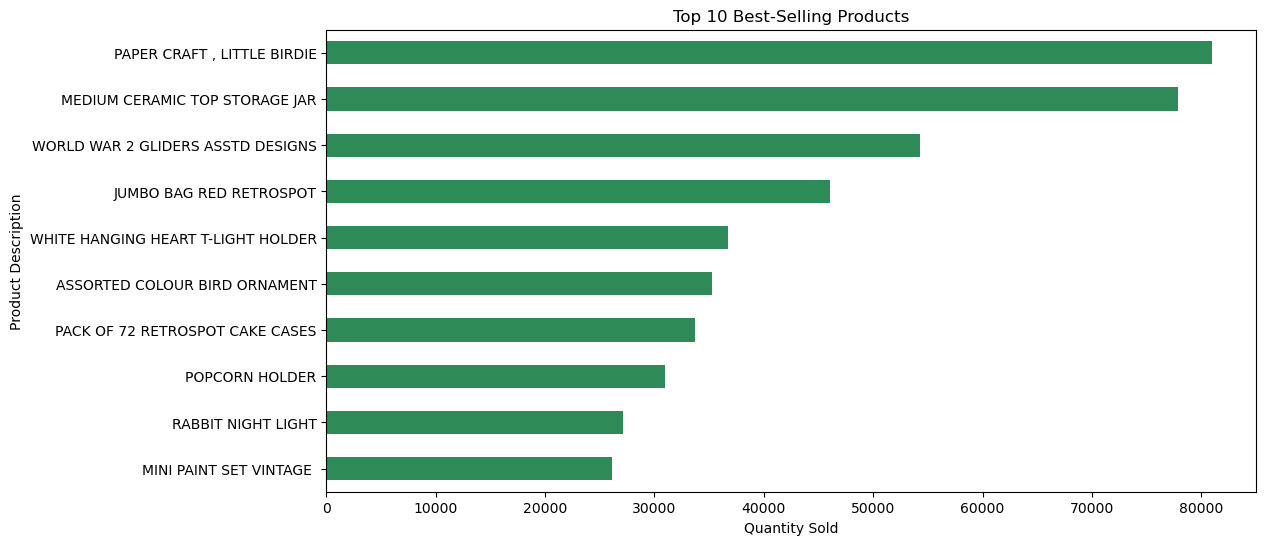

In [33]:
df_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
df_products.plot(kind="barh", color="seagreen")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Description")
plt.gca().invert_yaxis()  # To show the highest at the top
plt.show()


In [35]:
df_revenue = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
print(df_revenue)


Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64


In [37]:
df_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
print(df_customers)


CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64


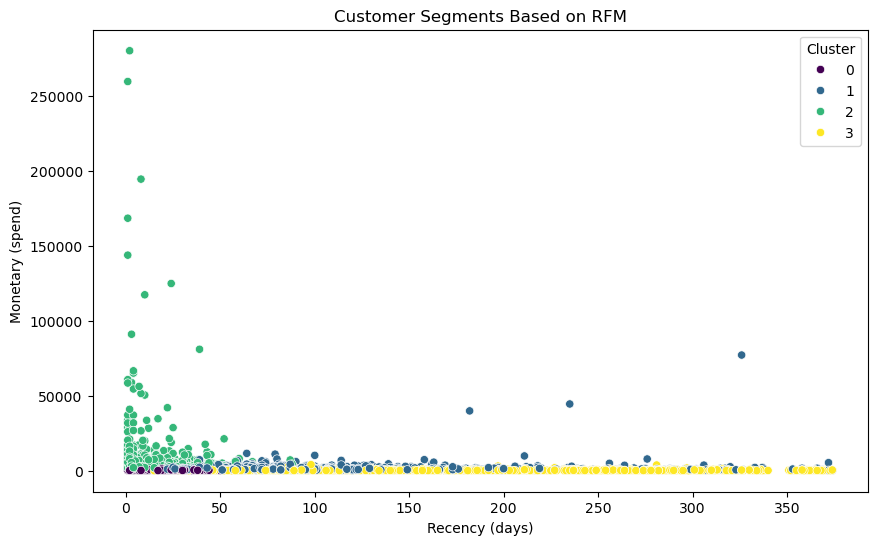

RFM Analysis and Clustering Done! 🚀


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime

# Load dataset (replace with actual file path)
df = pd.read_csv(r"C:\Users\Rakshitha\OneDrive\Desktop\rakshitha\FDS\cust-dna\archive (1)\data.csv", encoding='ISO-8859-1')

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove negative values (returns)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Compute TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Compute RFM Metrics
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'count',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Log transformation to normalize skewed data
rfm_log = np.log1p(rfm)

# Standardize the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rfm['Recency'], y=rfm['Monetary'], hue=rfm['Cluster'], palette='viridis')
plt.title('Customer Segments Based on RFM')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (spend)')
plt.show()

# Save clustered data
rfm.to_csv('rfm_clusters.csv', index=True)

print("RFM Analysis and Clustering Done! 🚀")


In [47]:
from sklearn.cluster import KMeans

k = 4  # Choose your optimal k based on the elbow method
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled)  # Assign clusters


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])  # Adjust column names as needed


In [53]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
print(f'Silhouette Score: {silhouette_avg}')


Silhouette Score: 0.03496653917545979


In [55]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f'For k={k}, Silhouette Score: {score}')


For k=2, Silhouette Score: 0.9311835523719525
For k=3, Silhouette Score: 0.6019775931686978
For k=4, Silhouette Score: 0.6000318625764626
For k=5, Silhouette Score: 0.615291500638006
For k=6, Silhouette Score: 0.5922769731235477
For k=7, Silhouette Score: 0.5279762827457551
For k=8, Silhouette Score: 0.5221081401371872
For k=9, Silhouette Score: 0.5206867932664937


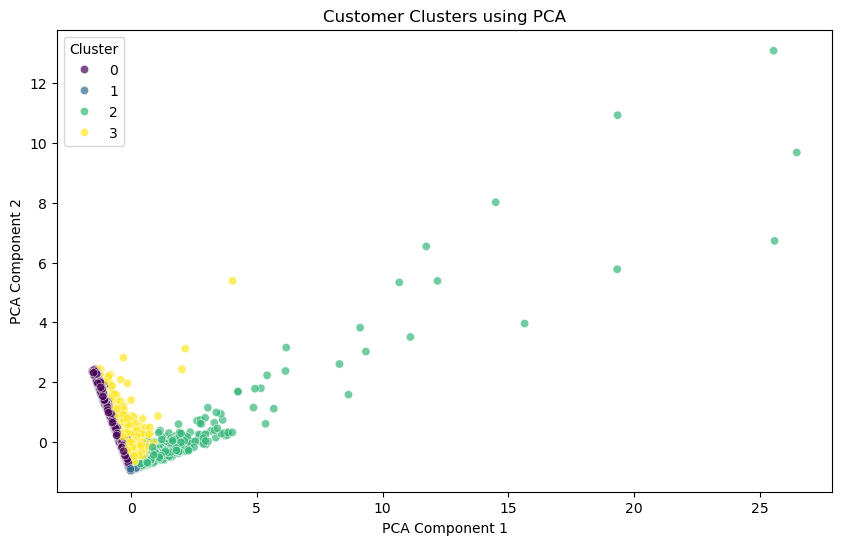

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create a scatter plot of the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=cluster_labels, palette='viridis', alpha=0.7)

# Add labels and title
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Clusters using PCA')
plt.legend(title='Cluster')
plt.show()


Silhouette Score for K=2: 0.4765179761677345


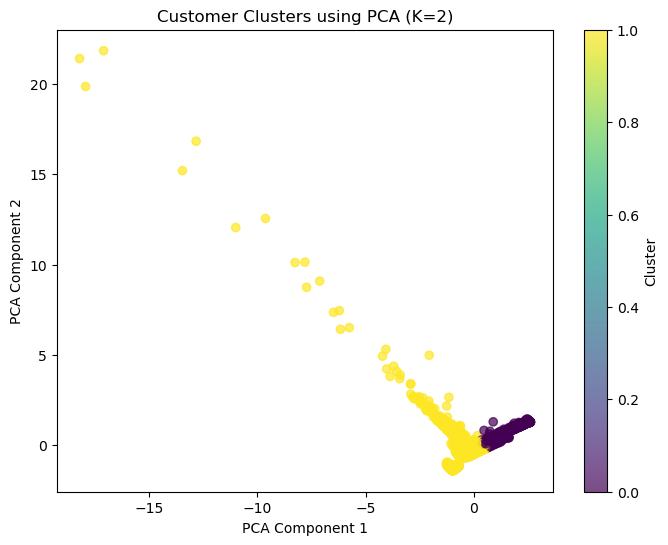

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Assuming 'rfm_data' is your RFM dataset
# Standardize the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


# Run K-Means with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# Calculate Silhouette Score
silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
print(f'Silhouette Score for K=2: {silhouette_avg}')

# Apply PCA for visualization
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Plot PCA results
plt.figure(figsize=(8,6))
plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters using PCA (K=2)")
plt.colorbar(label="Cluster")
plt.show()


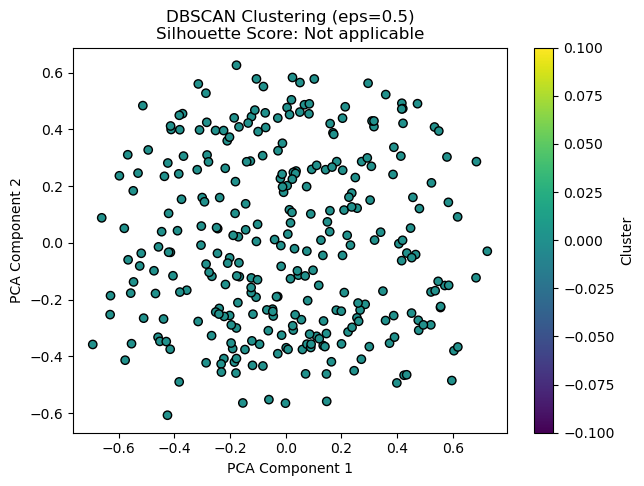

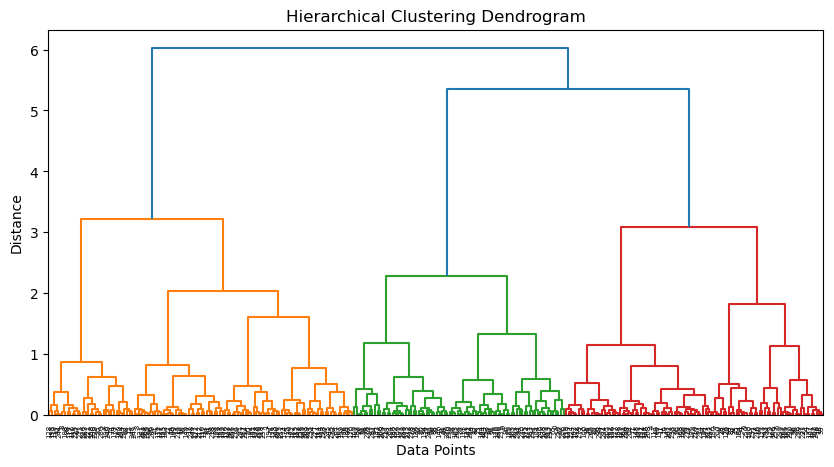

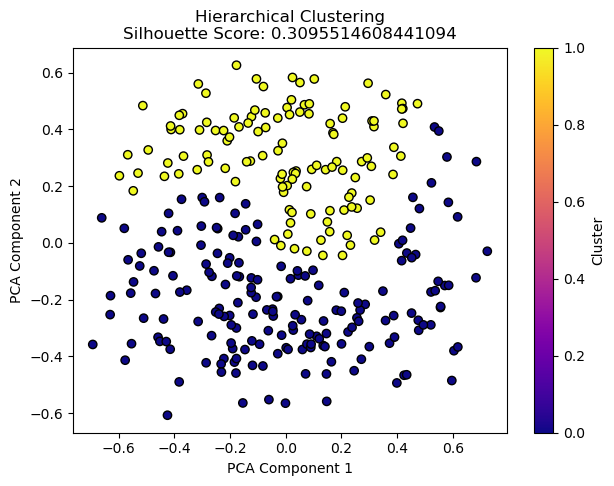

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load dataset (Replace with actual dataset)
# df = pd.read_csv("your_dataset.csv")
X = np.random.rand(300, 5)  # Example dataset with 5 features

# Apply PCA to reduce dimensions to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ------------------ DBSCAN ------------------ #
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

# Compute Silhouette Score (ignoring noise points)
if len(set(dbscan_labels)) > 1:
    sil_score_dbscan = silhouette_score(X_pca, dbscan_labels)
else:
    sil_score_dbscan = "Not applicable"

# Plot DBSCAN clusters
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, cmap='viridis', edgecolors='k')
plt.colorbar(label='Cluster')
plt.title(f'DBSCAN Clustering (eps=0.5)\nSilhouette Score: {sil_score_dbscan}')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ------------------ Hierarchical Clustering ------------------ #
hierarchical = AgglomerativeClustering(n_clusters=2)
hierarchical_labels = hierarchical.fit_predict(X_pca)

# Compute Silhouette Score
sil_score_hierarchical = silhouette_score(X_pca, hierarchical_labels)

# Plot Dendrogram
plt.figure(figsize=(10,5))
linkage_matrix = linkage(X_pca, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Plot Hierarchical Clusters
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hierarchical_labels, cmap='plasma', edgecolors='k')
plt.colorbar(label='Cluster')
plt.title(f'Hierarchical Clustering\nSilhouette Score: {sil_score_hierarchical}')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [71]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# Assuming `X` is the dataset used for clustering
# Assuming `labels` contains the cluster labels from hierarchical clustering

sil_score = silhouette_score(X, labels)
db_index = davies_bouldin_score(X, labels)

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_index:.4f}")


Silhouette Score: -0.1087
Davies-Bouldin Index: 0.7262


In [90]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset (adjust path as needed)
data = pd.read_csv(r"C:\Users\Rakshitha\OneDrive\Desktop\rakshitha\FDS\cust-dna\archive (1)\data.csv", encoding="ISO-8859-1")

# Check for numeric columns and apply scaling
numeric_data = data.select_dtypes(include=[np.number])  # Select only numeric columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)  # Normalize only numeric columns

# Optionally, keep non-numeric data and combine it back
non_numeric_data = data.select_dtypes(exclude=[np.number])  # Non-numeric columns
data_processed = pd.concat([pd.DataFrame(scaled_data, columns=numeric_data.columns), non_numeric_data], axis=1)

# Verify the data
print("Data processed successfully!", data_processed.shape)


Data processed successfully! (541909, 8)


In [92]:
print(data_processed.head())


   Quantity  UnitPrice  CustomerID InvoiceNo StockCode  \
0 -0.016289  -0.021301     1.49528    536365    85123A   
1 -0.016289  -0.012620     1.49528    536365     71053   
2 -0.007118  -0.019234     1.49528    536365    84406B   
3 -0.016289  -0.012620     1.49528    536365    84029G   
4 -0.016289  -0.012620     1.49528    536365    84029E   

                           Description     InvoiceDate         Country  
0   WHITE HANGING HEART T-LIGHT HOLDER  12/1/2010 8:26  United Kingdom  
1                  WHITE METAL LANTERN  12/1/2010 8:26  United Kingdom  
2       CREAM CUPID HEARTS COAT HANGER  12/1/2010 8:26  United Kingdom  
3  KNITTED UNION FLAG HOT WATER BOTTLE  12/1/2010 8:26  United Kingdom  
4       RED WOOLLY HOTTIE WHITE HEART.  12/1/2010 8:26  United Kingdom  


In [94]:
print(data_processed.isnull().sum())


Quantity            0
UnitPrice           0
CustomerID     135080
InvoiceNo           0
StockCode           0
Description      1454
InvoiceDate         0
Country             0
dtype: int64


In [101]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the data (adjust the file path as needed)
data = pd.read_csv(r"C:\Users\Rakshitha\OneDrive\Desktop\rakshitha\FDS\cust-dna\archive (1)\data.csv", encoding="ISO-8859-1")

# Handle missing values
# 1. Fill missing CustomerID with -1 (or can choose another placeholder like 'Unknown')
data['CustomerID'].fillna(-1, inplace=True)

# 2. Fill missing Description with a placeholder 'No description available'
data['Description'].fillna('No description available', inplace=True)

# 3. Fill missing UnitPrice and Quantity with the median
data['UnitPrice'].fillna(data['UnitPrice'].median(), inplace=True)
data['Quantity'].fillna(data['Quantity'].median(), inplace=True)

# Verify if missing values are handled
print("Missing values after handling:")
print(data.isnull().sum())

# Normalize numeric data if needed
scaler = StandardScaler()

# We can normalize specific numeric columns like 'Quantity', 'UnitPrice', and 'CustomerID'
data[['Quantity', 'UnitPrice', 'CustomerID']] = scaler.fit_transform(data[['Quantity', 'UnitPrice', 'CustomerID']])

# Print the first few rows to confirm changes
print("\nProcessed Data:")
print(data.head())


C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_18300\756197536.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CustomerID'].fillna(-1, inplace=True)
C:\Users\Rakshitha\AppData\Local\Temp\ipykernel_18300\756197536.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Missing values after handling:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Processed Data:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER -0.016289   
1    536365     71053                  WHITE METAL LANTERN -0.016289   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER -0.007118   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE -0.016289   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART. -0.016289   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26  -0.021301    0.940243  United Kingdom  
1  12/1/2010 8:26  -0.012620    0.940243  United Kingdom  
2  12/1/2010 8:26  -0.019234    0.940243  United Kingdom  
3  12/1/2010 8:26  -0.012620    0.940243  United Kingdom  
4  12/1/2010 8:26  -0.012620    0.940243  United Kingdom  
